# Optical pumping experiment

This notebook encompasses all of the data analysis for the PHYS 409 Optical pumping experiment.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [29]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename):
    ItB = (0.6*10e-4)#Teslas
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*5.000000e-03
    # filename, ext = os.path.splitext(filename)
    # new_filename = f"{filename}_B{ext}"
    # df.to_csv(new_filename, index=False)
    # print("New file:",new_filename) 
    return df

df_25 = add_magnetic_field("Data/NewFile25kHz.csv")
df_50 = add_magnetic_field("Data/NewFile50kHz.csv")
df_75 = add_magnetic_field("Data/NewFile75kHz.csv")
df_100 = add_magnetic_field("Data/NewFile100kHz.csv")
df_125 = add_magnetic_field("Data/NewFile125kHz.csv")
df_150 = add_magnetic_field("Data/NewFile150kHz.csv")
df_175 = add_magnetic_field("Data/NewFile175kHz.csv")
df_195 = add_magnetic_field("Data/NewFile195kHz.csv")

### Lorentzian fit of the data:

$$f(x;A,x_0,\gamma) = A\cdot\frac{\gamma^2}{\gamma^2+(x-x_0)^2}$$

Specific heat capacity is analogous to your trainability coefficient. You want the specific heat capacity to be as low as possible for quick change of temperature in solids, similarly you want high trainability for weights. inversely related.

$$T_b \propto \frac{1}{C}$$


Solomonoff induction is actually stupid as fuck bruah. it's just an induction process that takes you from arbitrarily deciding the truth/ or arbitrary delibartion of the truth of any matter to something more justifiable and realistic. Solomonoff induction is basically bayesian statistics, coupled with hypothesis testing (perhaps a close link to the scientific method).  

In [30]:
def lorentzian(x,ampl,center,hwhm):
    return ampl*((hwhm**2)/(hwhm**2+(x-center)**2))

[ 0.972832    2.97013271 12.68025238]


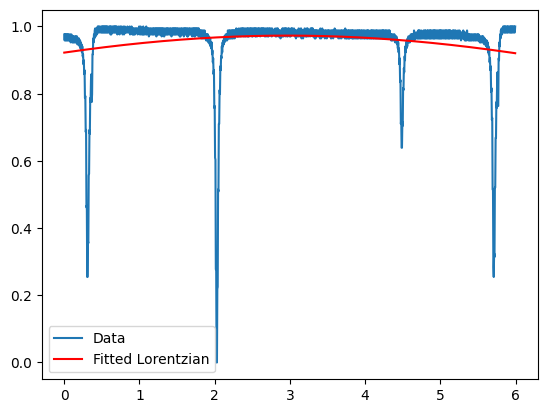

array([ 0.972832  ,  2.97013271, 12.68025238])

In [37]:
def fit_lorentzian(p0,df):
    x_data,y_data = df["time"],df["CH2norm"]
    popt, pcov = curve_fit(lorentzian,x_data,y_data,p0=p0)
    fitted_amplitude, fitted_center, fitted_hwhm = popt
    print(popt)
    plt.plot(x_data, y_data, label='Data')
    plt.plot(x_data, lorentzian(x_data, *popt), 'r-', label='Fitted Lorentzian')
    plt.legend()
    plt.show()
    return popt
fit_lorentzian([1,4,0.5],df_195)

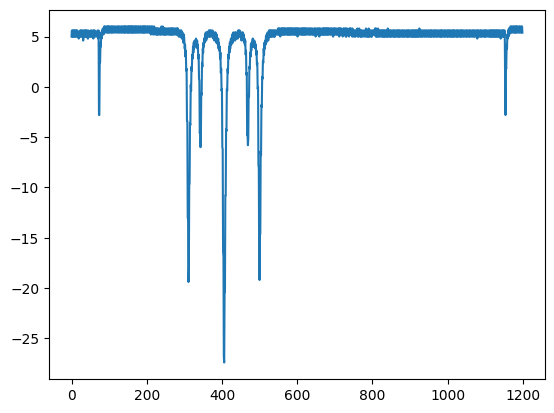

In [69]:
df = pd.read_csv("Data/NewFile25kHz.csv", skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
plt.plot(df["Sequence"], df["CH2"])
plt.show()